## Importing packages

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, recall_score, f1_score, precision_score

## Loading the personality dataset

In [4]:
df = pd.read_csv('personality_datasert.csv')
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


## Preprocessing the dataset

In this section, we will try to transform, manipulate and prepare the personality dataset for modelling and exploration. We will use binary encoding for features with two values and mean-standard deviation for our numerical features. This will ensure that our model performs better and trains faster.

In [5]:
# binary encoding
df['Stage_fear'] = df['Stage_fear'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Drained_after_socializing'] = df['Drained_after_socializing'].apply(lambda x:1 if x=='Yes' else 0)
df['Personality'] = df['Personality'].apply(lambda x: 1 if x == 'Extrovert' else 0)

# mean-sd normalisation
cols = ['Time_spent_Alone',	'Social_event_attendance',	'Going_outside',	'Friends_circle_size',	'Post_frequency']
for col in cols:
  df[col] = (df[col] - df[col].mean())/df[col].std()

df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,-0.146989,0,0.012757,1.350380,0,1.590405,0.496019,1
1,1.306001,1,-1.379706,-1.350380,1,-1.481181,-0.195165,0
2,1.306001,1,-1.031590,-0.450127,1,-0.299802,-0.540757,0
3,-1.309381,0,0.708988,1.800506,0,1.826681,1.532794,1
4,-0.437587,0,1.753336,0.450127,0,0.409026,0.496019,1


## Exploratory Data Analysis

In this section, we will be looking at the shape of the data, the distribution of each feature and the relationship between the features and the target variable.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   int64  
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   int64  
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   int64  
dtypes: float64(5), int64(3)
memory usage: 181.4 KB


We can observe that the dataset has no missing values as the number of entries in each column is the same.

array([[<Axes: title={'center': 'Time_spent_Alone'}>,
        <Axes: title={'center': 'Stage_fear'}>,
        <Axes: title={'center': 'Social_event_attendance'}>],
       [<Axes: title={'center': 'Going_outside'}>,
        <Axes: title={'center': 'Drained_after_socializing'}>,
        <Axes: title={'center': 'Friends_circle_size'}>],
       [<Axes: title={'center': 'Post_frequency'}>,
        <Axes: title={'center': 'Personality'}>, <Axes: >]], dtype=object)

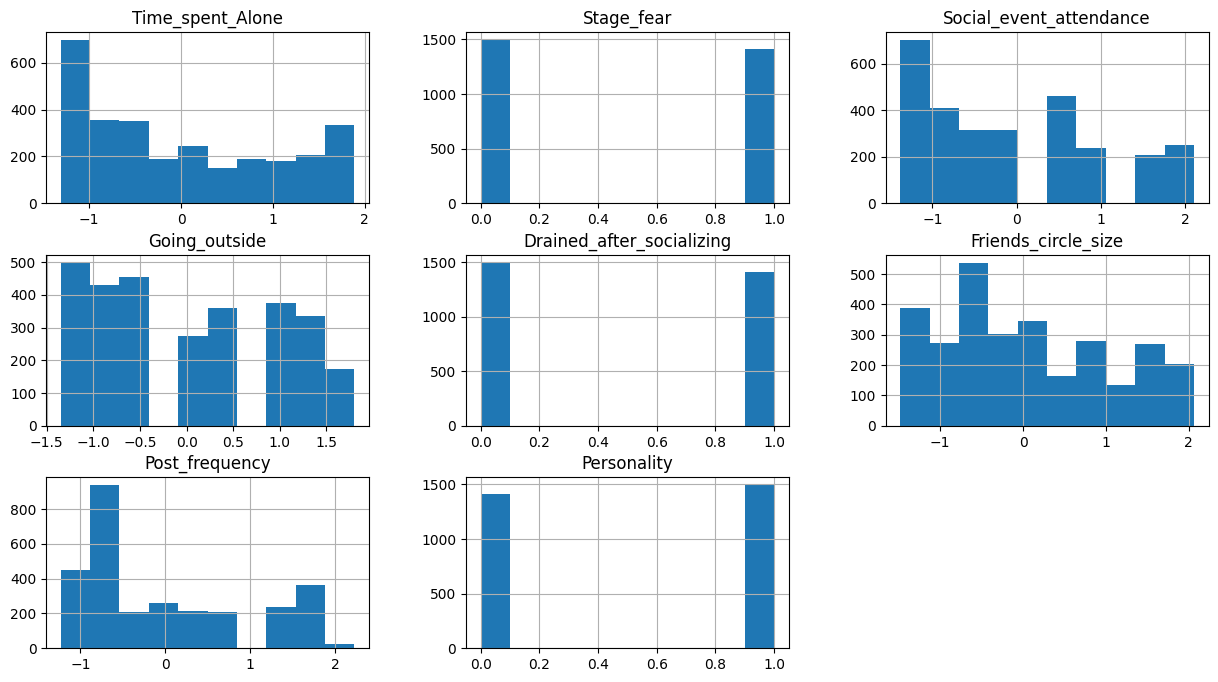

In [7]:
df.hist(figsize=(15, 8))

We can observe that our features are not normally distributed. This influences the choice of model, as some models assume that the input data follows a normal distribution.

<Axes: >

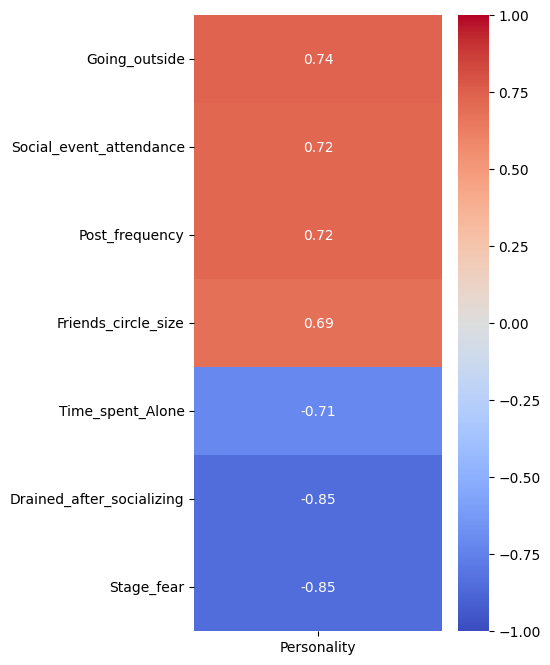

In [8]:
corr_matrix = df.corr(numeric_only=True).sort_values(by='Personality', ascending=False)
corr_matrix_no_personality = corr_matrix.drop('Personality')
plt.figure(figsize=(4, 8))
sns.heatmap(corr_matrix_no_personality[['Personality']], annot=True, cmap='coolwarm', vmin=-1, vmax=1)

We can observe that the linear relationships between the target variable and the features are consistent with real-world expectations:
- Individuals who spend more time outside and attend more social events tend to be extroverted, as they prefer interacting with others, whereas most introverts prefer solitude.
- Individuals who post more frequently on social media and have larger friendship circles also tend to be extroverted, while introverts are more inclined to observe rather than actively engage.
- Individuals who spend more time alone and feel drained after social interactions are more likely to be introverted, as they prefer personal space after social engagement. In contrast, extroverts tend to spend less time alone and feel less socially drained.
- Individuals who experience stage fear are more likely to be introverted, as many introverts experience social anxiety, whereas extroverts are generally more socially confident and less affected by stage fear.

## Splitting the dataset into training, validation and testing sets

In [9]:
X = df[['Time_spent_Alone', 'Stage_fear',	'Social_event_attendance',	'Going_outside', 'Drained_after_socializing','Friends_circle_size',	'Post_frequency']]
y = df['Personality']
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.3, random_state=42, stratify=y_temp)
print(f'X_train shape: {X_train.shape[0]}')
print(f'X_val shape: {X_val.shape[0]}')
print(f'X_test shape: {X_test.shape[0]}')

X_train shape: 1421
X_val shape: 609
X_test shape: 870


## Defining and training the model

In [10]:
import xgboost as xgb
# ----------------------------------------------------------
# MODEL + PIPELINE
# ----------------------------------------------------------
xgb_clf = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist"
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", xgb_clf)
])

# ----------------------------------------------------------
# SEARCH SPACE
# ----------------------------------------------------------
param_dist = {
    "model__n_estimators": [200, 400, 600, 800],
    "model__learning_rate": np.linspace(0.01, 0.3, 10),
    "model__max_depth": [3, 4, 5, 6, 8, 10],
    "model__min_child_weight": [1, 3, 5, 7, 10],
    "model__subsample": np.linspace(0.6, 1.0, 5),
    "model__colsample_bytree": np.linspace(0.6, 1.0, 5),
    "model__gamma": [0, 0.1, 0.2, 0.5, 1.0],
    "model__reg_lambda": [0.01, 0.1, 1, 5, 10],
    "model__reg_alpha": [0, 0.01, 0.1, 1]
}

# ----------------------------------------------------------
# RANDOM SEARCH (robust + efficient)
# ----------------------------------------------------------
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=50,
    scoring="f1",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

# ----------------------------------------------------------
# BEST MODEL
# ----------------------------------------------------------
best_model = search.best_estimator_

print("Best params:", search.best_params_)

# ----------------------------------------------------------
# PERFORMANCE ON VALIDATION
# ----------------------------------------------------------
y_pred_valid = best_model.predict(X_val)

print("VALIDATION PERFORMANCE")
print("Accuracy:", accuracy_score(y_val, y_pred_valid))
print("Recall:", recall_score(y_val, y_pred_valid))
print("Precision:", precision_score(y_val, y_pred_valid))
print("F1 Score:", f1_score(y_val, y_pred_valid))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'model__subsample': np.float64(1.0), 'model__reg_lambda': 0.1, 'model__reg_alpha': 1, 'model__n_estimators': 600, 'model__min_child_weight': 5, 'model__max_depth': 8, 'model__learning_rate': np.float64(0.1711111111111111), 'model__gamma': 0.5, 'model__colsample_bytree': np.float64(0.9)}
VALIDATION PERFORMANCE
Accuracy: 0.9359605911330049
Recall: 0.9329073482428115
Precision: 0.9419354838709677
F1 Score: 0.9373996789727127


## Model Evaluation

Accuracy: 0.9356321839080459
Recall: 0.9217002237136466
Precision: 0.9515011547344111
F1 Score: 0.9363636363636364


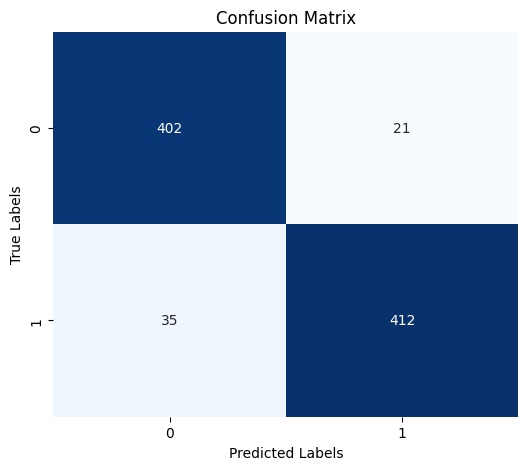

In [11]:
y_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
recall_s = recall_score(y_test, y_pred)
f1_s = f1_score(y_test, y_pred)
precision_s = precision_score(y_test, y_pred)
print(f'Accuracy: {test_acc}')
print(f'Recall: {recall_s}')
print(f'Precision: {precision_s}')
print(f'F1 Score: {f1_s}')
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot with seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## Saving the model

In [12]:
#from google.colab import files
#import joblib

#joblib.dump(best_model, 'personality_model.pkl')
#files.download('personality_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>